Metrics for Default SVM Parameters:
F1 Score: 0.8920984129649846 - Precision: 0.9470493849170976 - Accuracy: 0.9034923019151333
Confusion Matrix:
[[6718  297]
 [ 988 5312]]

Rates: {'TPR': 0.8431746031746031, 'TNR': 0.9576621525302922, 'FPR': 0.04233784746970777, 'FNR': 0.1568253968253968}



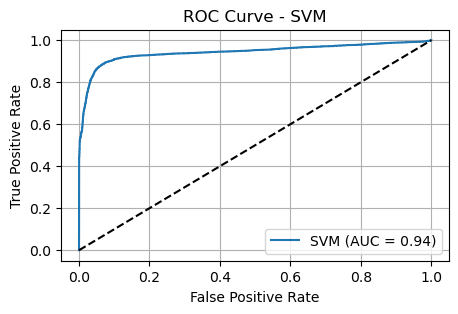

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load CSV files
# train_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_synthetic_train.csv"
# test_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X_train, X_test, y_train, y_test = train_test_split(
    train_data.drop('Label', axis=1), train_data['Label'], test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the default SVM model
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

# Predictions and metrics
preds = svm_model.predict(X_test_scaled)
f1 = f1_score(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    return {
        'TPR': TP / (TP + FN),
        'TNR': TN / (TN + FP),
        'FPR': FP / (FP + TN),
        'FNR': FN / (FN + TP)
    }

rates = compute_rates(conf_matrix)

# Output the results
print(f'Metrics for Default SVM Parameters:')
print(f'F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}\n')
print(f'Rates: {rates}\n')

# ROC and AUC - SVM model must be fit with probability=True to use decision_function
svm_model_with_prob = SVC(probability=True)
svm_model_with_prob.fit(X_train_scaled, y_train)
roc_score = roc_auc_score(y_test, svm_model_with_prob.decision_function(X_test_scaled))
fpr, tpr, _ = roc_curve(y_test, svm_model_with_prob.decision_function(X_test_scaled))

# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM Home C_sim')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\SVM_ROC_sim.png', bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load CSV files
# train_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_synthetic_train.csv"
# test_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_real_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X_train, X_test, y_train, y_test = train_test_split(
    train_data.drop('Label', axis=1), train_data['Label'], test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the default SVM model
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

# Predictions and metrics
preds = svm_model.predict(X_test_scaled)
f1 = f1_score(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    return {
        'TPR': TP / (TP + FN),
        'TNR': TN / (TN + FP),
        'FPR': FP / (FP + TN),
        'FNR': FN / (FN + TP)
    }

rates = compute_rates(conf_matrix)

# Output the results
print(f'Metrics for Default SVM Parameters:')
print(f'F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}\n')
print(f'Rates: {rates}\n')

# ROC and AUC - SVM model must be fit with probability=True to use decision_function
svm_model_with_prob = SVC(probability=True)
svm_model_with_prob.fit(X_train_scaled, y_train)
roc_score = roc_auc_score(y_test, svm_model_with_prob.decision_function(X_test_scaled))
fpr, tpr, _ = roc_curve(y_test, svm_model_with_prob.decision_function(X_test_scaled))

# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM Home C_Real ')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\SVM_ROC_real.png', bbox_inches='tight')
plt.show()

Metrics for Default SVM Parameters:
F1 Score: 0.8920984129649846 - Precision: 0.9470493849170976 - Accuracy: 0.9034923019151333
Confusion Matrix:
[[6718  297]
 [ 988 5312]]

Rates: {'TPR': 0.8431746031746031, 'TNR': 0.9576621525302922, 'FPR': 0.04233784746970777, 'FNR': 0.1568253968253968}

